Preliminary Wrangling

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [2]:
gbf= pd.read_csv('fordgobike-tripdataFor201902.csv')

In [3]:
gbf.shape # عدد الصفوف والاعمدهههه

(183416, 16)

In [4]:
gbf.dtypes 

duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object

In [5]:
gbf.head(15) # هنعرض خمستاشر صف

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,49:58.6,19:51.8,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No
6,1147,55:35.1,14:42.6,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,-121.901782,3803,Subscriber,1983.0,Female,No
7,1615,41:06.8,08:02.8,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6329,Subscriber,1989.0,Male,No
8,1570,41:48.8,07:59.7,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,-122.421025,6548,Subscriber,1988.0,Other,No
9,1049,49:47.7,07:17.0,19.0,Post St at Kearny St,37.788975,-122.403452,121.0,Mission Playground,37.759210,-122.421339,6488,Subscriber,1992.0,Male,No


In [6]:
gbf.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [7]:
gbf.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [8]:
gbf.isnull().sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

In [9]:
gbf = gbf.dropna(subset=['start_station_id', 'start_station_name',
                          'end_station_id', 'end_station_name',
                          'member_birth_year'])

In [10]:
gbf.isnull().sum()


duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [11]:
gbf.member_gender.value_counts(dropna=False)

member_gender
Male      130504
Female     40805
Other       3647
Name: count, dtype: int64

In [12]:
gbf['member_gender'] = gbf['member_gender'].fillna('Unknown')

In [13]:
gbf.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [14]:
gbf.duplicated().sum()

np.int64(4)

In [15]:
gbf.select_dtypes(include='str').nunique()

start_time                 35732
end_time                   35717
start_station_name           329
end_station_name             329
user_type                      2
member_gender                  3
bike_share_for_all_trip        2
dtype: int64

In [16]:
gbf['user_type'] = gbf['user_type'].astype('category')
gbf['member_gender'] = gbf['member_gender'].astype('category')
gbf['bike_share_for_all_trip'] = gbf['bike_share_for_all_trip'].astype('category')

gbf.dtypes

duration_sec                  int64
start_time                      str
end_time                        str
start_station_id            float64
start_station_name              str
start_station_latitude      float64
start_station_longitude     float64
end_station_id              float64
end_station_name                str
end_station_latitude        float64
end_station_longitude       float64
bike_id                       int64
user_type                  category
member_birth_year           float64
member_gender              category
bike_share_for_all_trip    category
dtype: object

In [17]:
gbf['age'] = 2019 - gbf['member_birth_year']

gbf[['member_birth_year', 'age']].head()

,member_birth_year,age
0,1984.0,35.0
2,1972.0,47.0
3,1989.0,30.0
4,1974.0,45.0
5,1959.0,60.0


In [18]:
gbf['age'] = gbf['age'].astype(int)

In [19]:
def average_age(df):
    return df['age'].mean()

average_age(gbf)

np.float64(34.19679805208167)

In [20]:
gbf['duration_min'] = gbf['duration_sec'] / 60

In [21]:
gbf['duration_hour'] = gbf['duration_sec'] / 3600

In [22]:
gbf[['duration_sec', 'duration_min', 'duration_hour', 'age']].head()

,duration_sec,duration_min,duration_hour,age
0,52185,869.750000,14.495833,35
2,61854,1030.900000,17.181667,47
3,36490,608.166667,10.136111,30
4,1585,26.416667,0.440278,45
5,1793,29.883333,0.498056,60


Univariate Exploration


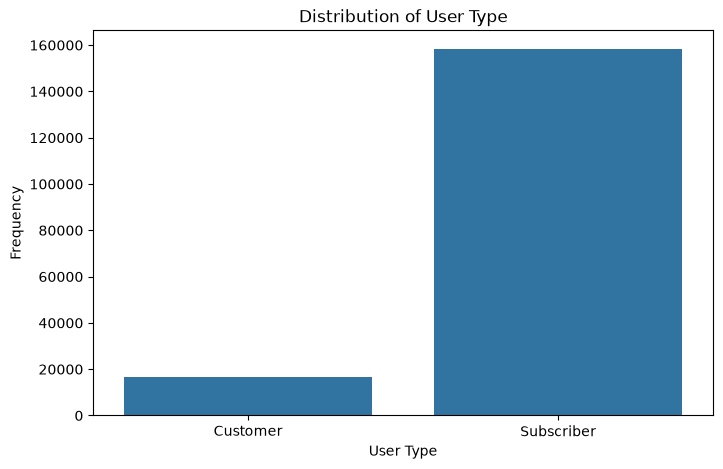

In [23]:
plt.figure(figsize=(8,5))
sb.countplot(data=gbf, x='user_type')
plt.xlabel('User Type')
plt.ylabel('Frequency')
plt.title("Distribution of User Type")
plt.show()

The majority of trips (~160,000) were made by users NOT enrolled in the "bike share for all" program, while only a small fraction (~18,000) were. This indicates that this program serves a niche subset of users rather than the general rider base.

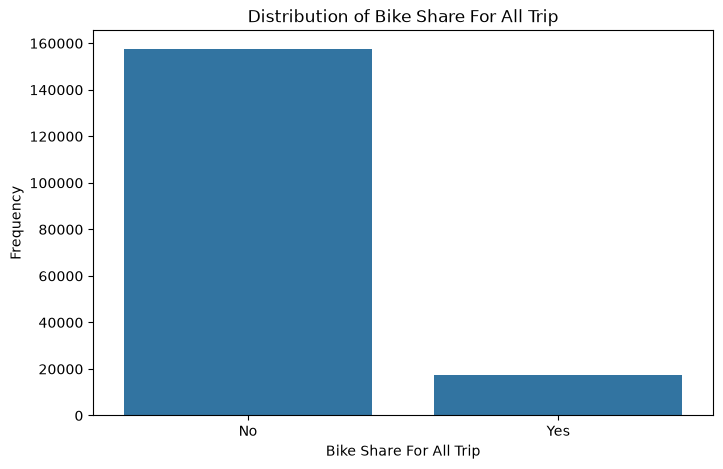

In [24]:
plt.figure(figsize=(8,5))
sb.countplot(data=gbf, x='bike_share_for_all_trip')
plt.xlabel('Bike Share For All Trip')
plt.ylabel('Frequency')
plt.title("Distribution of Bike Share For All Trip")
plt.show()


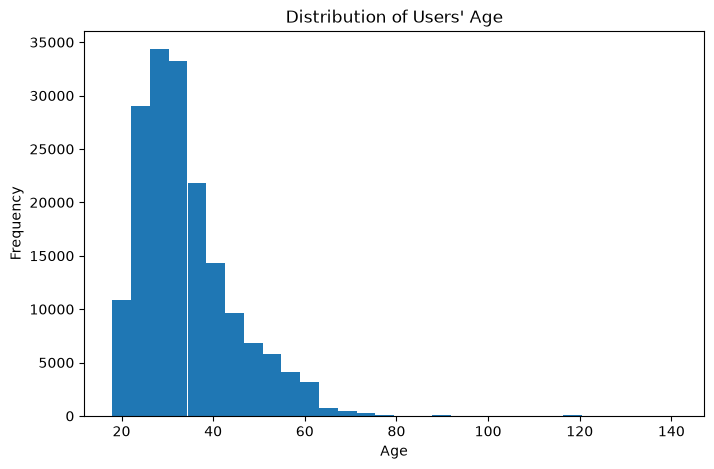

In [25]:
plt.figure(figsize=(8,5))
plt.hist(data=gbf, x='age', bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Distribution of Users' Age")
plt.show()

In [26]:
gbf['age'].describe()

count    174956.000000
mean         34.196798
std          10.118631
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max         141.000000
Name: age, dtype: float64

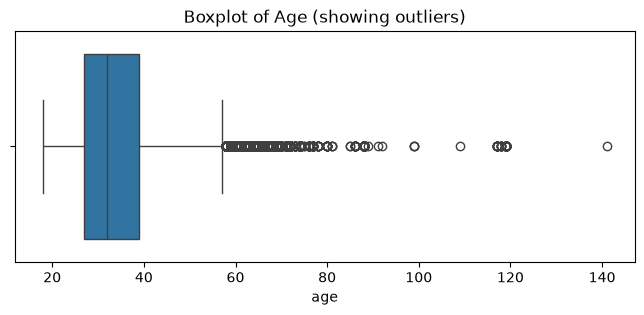

In [27]:
plt.figure(figsize=(8,3))
sb.boxplot(x=gbf['age'])
plt.title("Boxplot of Age (showing outliers)")
plt.show()

In [28]:
gbf['duration_min'].describe()

count    174956.000000
mean         11.733193
std          27.369797
min           1.016667
25%           5.383333
50%           8.500000
75%          13.150000
max        1409.133333
Name: duration_min, dtype: float64

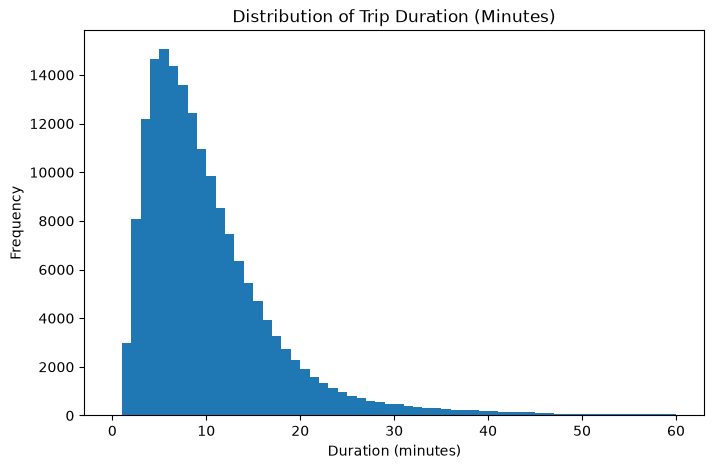

In [29]:
plt.figure(figsize=(8,5))
plt.hist(data=gbf, x='duration_min', bins=60, range=(0,60))
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.title("Distribution of Trip Duration (Minutes)")
plt.show()

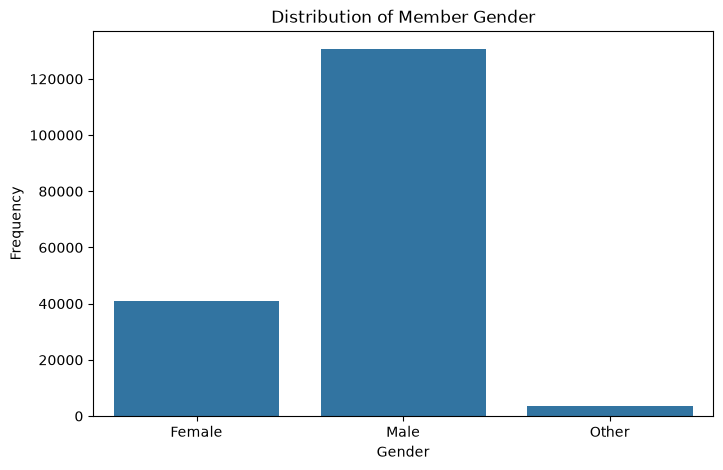

In [30]:
plt.figure(figsize=(8,5))
sb.countplot(data=gbf, x='member_gender')
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title("Distribution of Member Gender")
plt.show()

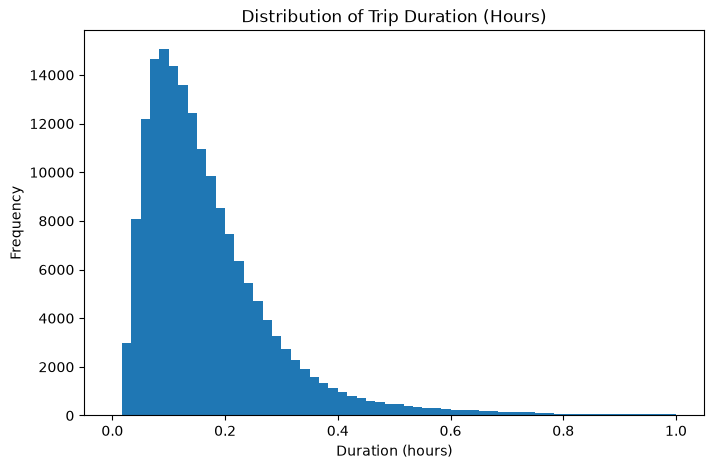

In [31]:
plt.figure(figsize=(8,5))
plt.hist(data=gbf, x='duration_hour', bins=60, range=(0,1))
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')
plt.title("Distribution of Trip Duration (Hours)")
plt.show()

Bivariate Exploration :

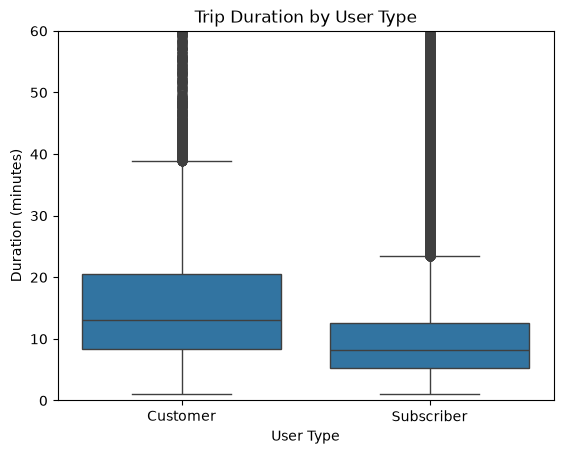

In [32]:
sb.boxplot(data=gbf, x='user_type', y='duration_min')
plt.ylim(0, 60)
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')
plt.title("Trip Duration by User Type")
plt.show()

Customers tend to have longer trip durations (median 13 minutes) compared to Subscribers (median 8 minutes). This suggests Subscribers use the service for quick, routine commuting, while Customers may use it more casually.

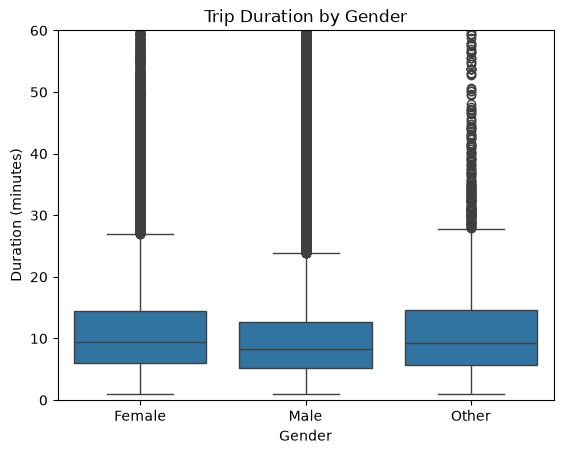

In [33]:
sb.boxplot(data=gbf, x='member_gender', y='duration_min')
plt.ylim(0, 60)
plt.xlabel('Gender')
plt.ylabel('Duration (minutes)')
plt.title("Trip Duration by Gender")
plt.show()

Trip duration is fairly similar across genders, with Female and Other users having a slightly higher median duration (9 minutes) compared to Male users
 (8 minutes).

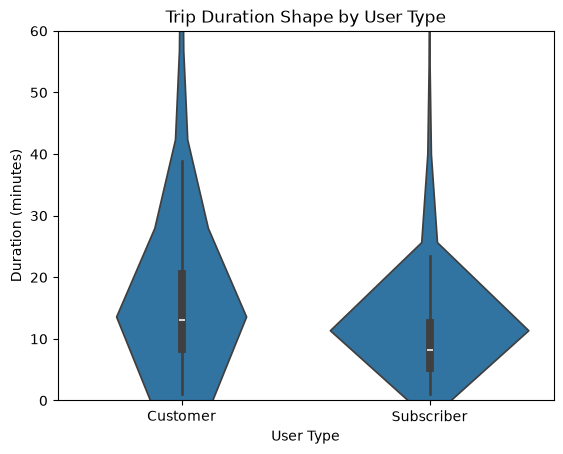

In [34]:
sb.violinplot(data=gbf, x='user_type', y='duration_min')
plt.ylim(0, 60)
plt.xlabel('User Type')
plt.ylabel('Duration (minutes)')
plt.title("Trip Duration Shape by User Type")
plt.show()

Subscribers =  trip durations are concentrated around 5-10 minutes, reflecting routine commuting. 
Customers =
 show a wider, more spread-out distribution.

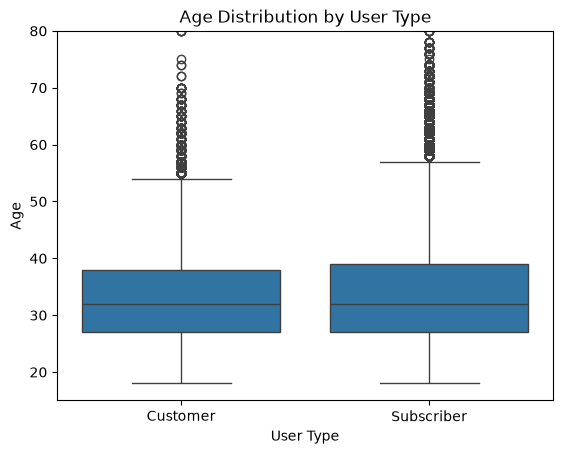

In [35]:
sb.boxplot(data=gbf, x='user_type', y='age')
plt.ylim(15, 80)
plt.xlabel('User Type')
plt.ylabel('Age')
plt.title("Age Distribution by User Type")
plt.show()

Age shows almost no difference between Customers and Subscribers 
 both have a median age of around 32                           

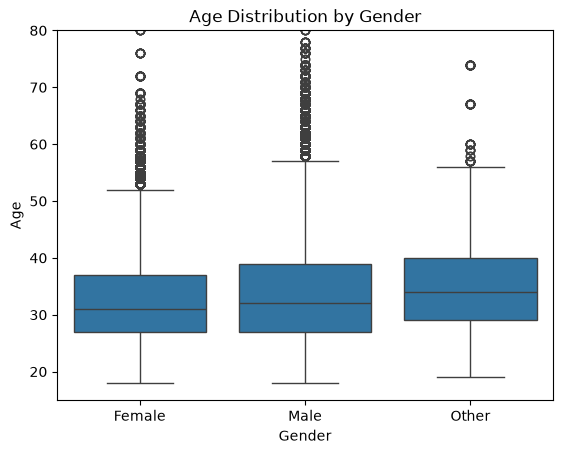

In [36]:
sb.boxplot(data=gbf, x='member_gender', y='age')
plt.ylim(15, 80)
plt.xlabel('Gender')
plt.ylabel('Age')
plt.title("Age Distribution by Gender")
plt.show()

Trip duration was the feature that varied the most —
 Subscribers had shorter more consistent trips (median 8 min) than Customer (median 13 min)

Age didn't really change with user_type or gender Gender had a small effect on duration and age,
 with Other users being slightly older on average

Multivariate Exploration :

In [37]:
gbf.select_dtypes(include=['int64', 'float64']).columns
gbf.corr(numeric_only=True)

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year,age,duration_min,duration_hour
duration_sec,1.000000,-0.006877,0.012244,-0.040952,0.002550,0.012861,-0.041443,0.011040,-0.006043,0.006043,1.000000,1.000000
start_station_id,-0.006877,1.000000,-0.195422,0.465138,0.339928,-0.184335,0.472381,-0.068103,0.115117,-0.115117,-0.006877,-0.006877
start_station_latitude,0.012244,-0.195422,1.000000,-0.678132,-0.184516,0.990131,-0.683579,0.051145,-0.075246,0.075246,0.012244,0.012244
start_station_longitude,-0.040952,0.465138,-0.678132,1.000000,0.485902,-0.682624,0.992508,-0.144054,0.125352,-0.125352,-0.040952,-0.040952
end_station_id,0.002550,0.339928,-0.184516,0.485902,1.000000,-0.202519,0.475511,-0.056786,0.112711,-0.112711,0.002550,0.002550
end_station_latitude,0.012861,-0.184335,0.990131,-0.682624,-0.202519,1.000000,-0.685111,0.050513,-0.075347,0.075347,0.012861,0.012861
end_station_longitude,-0.041443,0.472381,-0.683579,0.992508,0.475511,-0.685111,1.000000,-0.145890,0.126197,-0.126197,-0.041443,-0.041443
bike_id,0.011040,-0.068103,0.051145,-0.144054,-0.056786,0.050513,-0.145890,1.000000,0.036220,-0.036220,0.011040,0.011040
member_birth_year,-0.006043,0.115117,-0.075246,0.125352,0.112711,-0.075347,0.126197,0.036220,1.000000,-1.000000,-0.006043,-0.006043
age,0.006043,-0.115117,0.075246,-0.125352,-0.112711,0.075347,-0.126197,-0.036220,-1.000000,1.000000,0.006043,0.006043


There is no correlation between duration and any other numeric variable
 The only strong correlations are between duration units,
 member_birth_year/age (expected, derived), 
 and station coordinates (expected, geographic)

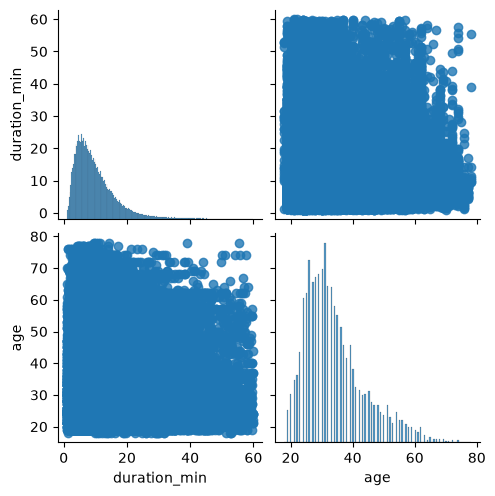

In [40]:
sb.pairplot(gbf_filtered, vars=['duration_min', 'age'], kind='reg')
plt.show()

The scatter =
 plots confirm there is no meaningful linear relationship between duration and age

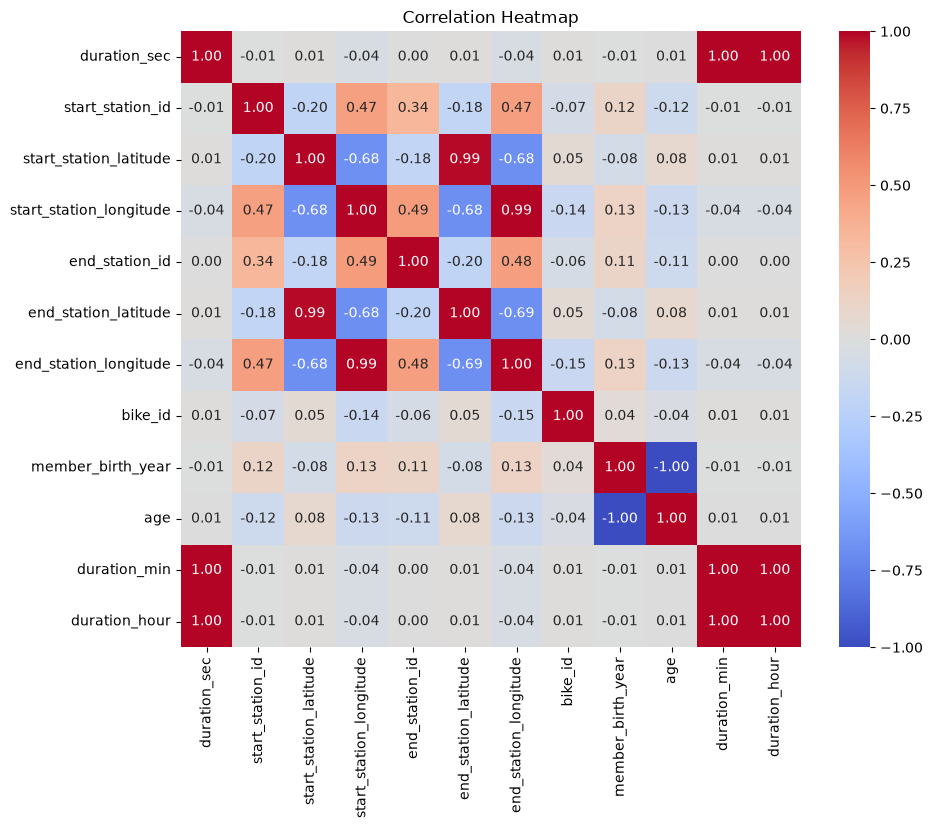

In [41]:
plt.figure(figsize=(10,8))
sb.heatmap(gbf.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Conclusions
   Most users are Male, then Female, then a small "Other" group.
    Most users are Subscribers, not Customers
    Trips are usually short — 5 to 10 minutes
    Subscribers take shorter, steadier trips than Customers.
    Age doesn't really affect user_type or gender.
    Duration isn't correlated with any other variable
### limitation
Some data was missing — we dropped station nulls and filled gender with "Unknown"
Some ages were unrealistic (up to 140) probably wrong birth years.
Data only covers one month so we can't see seasonal patterns.